In [91]:
# ==============================
# IMPORT LIBRARY
# ==============================
# Mengimpor library yang dibutuhkan
import pandas as pd
import numpy as np
# Library untuk modeling dan evaluasi
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [92]:
# ==============================
# LOAD DATA
# ==============================
# Membaca dataset
df = pd.read_csv(r'C:\Users\ASUS\Downloads\rideshare_kaggle.csv')
df.head()

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


In [93]:
# Melihat informasi dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           693071 non-null  str    
 1   timestamp                    693071 non-null  float64
 2   hour                         693071 non-null  int64  
 3   day                          693071 non-null  int64  
 4   month                        693071 non-null  int64  
 5   datetime                     693071 non-null  str    
 6   timezone                     693071 non-null  str    
 7   source                       693071 non-null  str    
 8   destination                  693071 non-null  str    
 9   cab_type                     693071 non-null  str    
 10  product_id                   693071 non-null  str    
 11  name                         693071 non-null  str    
 12  price                        637976 non-null  float64
 13  distance  

In [94]:
# Melihat statistik deskriptif dataset
df.describe()

,timestamp,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
count,6.930710e+05,693071.000000,693071.000000,693071.000000,637976.000000,693071.000000,693071.000000,693071.000000,693071.000000,693071.000000,...,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05
mean,1.544046e+09,11.619137,17.794365,11.586684,16.545125,2.189430,1.013870,42.338172,-71.066151,39.584388,...,0.037374,1.544044e+09,33.457774,1.544042e+09,45.261313,1.544047e+09,29.731002,1.544048e+09,41.997343,1.544048e+09
std,6.891925e+05,6.948114,9.982286,0.492429,9.324359,1.138937,0.091641,0.047840,0.020302,6.726084,...,0.055214,6.912028e+05,6.467224,6.901954e+05,5.645046,6.901353e+05,7.110494,6.871862e+05,6.936841,6.910777e+05
min,1.543204e+09,0.000000,1.000000,11.000000,2.500000,0.020000,1.000000,42.214800,-71.105400,18.910000,...,0.000000,1.543162e+09,15.630000,1.543122e+09,33.510000,1.543154e+09,11.810000,1.543136e+09,28.950000,1.543187e+09
25%,1.543444e+09,6.000000,13.000000,11.000000,9.000000,1.280000,1.000000,42.350300,-71.081000,36.450000,...,0.000000,1.543421e+09,30.170000,1.543399e+09,42.570000,1.543439e+09,27.760000,1.543399e+09,36.570000,1.543439e+09
50%,1.543737e+09,12.000000,17.000000,12.000000,13.500000,2.160000,1.000000,42.351900,-71.063100,40.490000,...,0.000400,1.543770e+09,34.240000,1.543727e+09,44.680000,1.543788e+09,30.130000,1.543745e+09,40.950000,1.543788e+09
75%,1.544828e+09,18.000000,28.000000,12.000000,22.500000,2.920000,1.000000,42.364700,-71.054200,43.580000,...,0.091600,1.544807e+09,38.880000,1.544789e+09,46.910000,1.544814e+09,35.710000,1.544789e+09,44.120000,1.544818e+09
max,1.545161e+09,23.000000,30.000000,12.000000,97.500000,7.860000,3.000000,42.366100,-71.033000,57.220000,...,0.145900,1.545152e+09,43.100000,1.545192e+09,57.870000,1.545109e+09,40.050000,1.545134e+09,57.200000,1.545109e+09


In [95]:
# Melihat jumlah nilai yang hilang di setiap kolom
df.isnull().sum()

id                                 0
timestamp                          0
hour                               0
day                                0
month                              0
datetime                           0
timezone                           0
source                             0
destination                        0
cab_type                           0
product_id                         0
name                               0
price                          55095
distance                           0
surge_multiplier                   0
latitude                           0
longitude                          0
temperature                        0
apparentTemperature                0
short_summary                      0
long_summary                       0
precipIntensity                    0
precipProbability                  0
humidity                           0
windSpeed                          0
windGust                           0
windGustTime                       0
v

In [96]:
# Melihat jumlah duplikat
duplikat = df.duplicated().sum()
print("Duplikat : ",duplikat)

Duplikat :  0


In [97]:
#menghapus nilai kosong pada kolom price
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])
df = df.reset_index(drop=True)

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 637976 entries, 0 to 637975
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           637976 non-null  str    
 1   timestamp                    637976 non-null  float64
 2   hour                         637976 non-null  int64  
 3   day                          637976 non-null  int64  
 4   month                        637976 non-null  int64  
 5   datetime                     637976 non-null  str    
 6   timezone                     637976 non-null  str    
 7   source                       637976 non-null  str    
 8   destination                  637976 non-null  str    
 9   cab_type                     637976 non-null  str    
 10  product_id                   637976 non-null  str    
 11  name                         637976 non-null  str    
 12  price                        637976 non-null  float64
 13  distance  

In [99]:
df.isnull().sum()

id                             0
timestamp                      0
hour                           0
day                            0
month                          0
datetime                       0
timezone                       0
source                         0
destination                    0
cab_type                       0
product_id                     0
name                           0
price                          0
distance                       0
surge_multiplier               0
latitude                       0
longitude                      0
temperature                    0
apparentTemperature            0
short_summary                  0
long_summary                   0
precipIntensity                0
precipProbability              0
humidity                       0
windSpeed                      0
windGust                       0
windGustTime                   0
visibility                     0
temperatureHigh                0
temperatureHighTime            0
temperatur

In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 637976 entries, 0 to 637975
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           637976 non-null  str    
 1   timestamp                    637976 non-null  float64
 2   hour                         637976 non-null  int64  
 3   day                          637976 non-null  int64  
 4   month                        637976 non-null  int64  
 5   datetime                     637976 non-null  str    
 6   timezone                     637976 non-null  str    
 7   source                       637976 non-null  str    
 8   destination                  637976 non-null  str    
 9   cab_type                     637976 non-null  str    
 10  product_id                   637976 non-null  str    
 11  name                         637976 non-null  str    
 12  price                        637976 non-null  float64
 13  distance  

In [101]:
#Mengecek Outlier pada kolom price menggunakan metode IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(outliers)

                                          id     timestamp  hour  day  month  \
645     6c187b77-cfab-4fc2-87ae-ce6caf756e35  1.543402e+09    10   28     11   
646     77644bac-cb00-4368-8aef-a3d0fd7861c2  1.544928e+09     2   16     12   
706     8e4bd9d1-d823-4f20-8dca-42d22da91002  1.544808e+09    17   14     12   
1005    3bebdd9d-17d7-47e0-9d92-2a08a56693d3  1.543770e+09    17    2     12   
1210    91182a5d-dc85-4870-acb3-bc31604d15ab  1.544977e+09    16   16     12   
...                                      ...           ...   ...  ...    ...   
637394  ec85457f-b575-42a8-8ff7-8bdf2ee666a8  1.545078e+09    20   17     12   
637637  1d2bc447-5fcf-4fa0-a4fc-5838e07abeff  1.544782e+09    10   14     12   
637813  f10c8d27-d2c9-4e16-9762-1d35fdd56561  1.543816e+09     5    3     12   
637878  006c270a-bfa8-450f-9628-2d6667e55560  1.543727e+09     4    2     12   
637917  c12672b4-2a17-422a-a72f-815d4ed75281  1.544725e+09    18   13     12   

                   datetime          ti

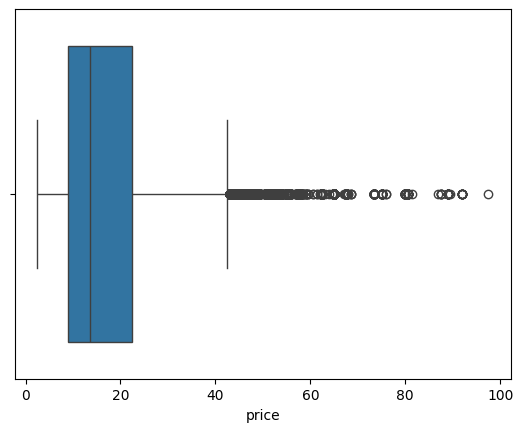

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['price'])
plt.show()

In [103]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['price'] = df['price'].clip(lower, upper)

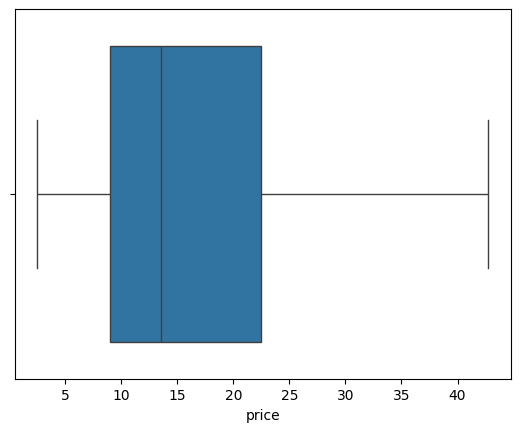

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['price'])
plt.show()

In [105]:
# ==============================
# FEATURE SELECTION (BERDASARKAN KORELASI)
# ==============================
# Memilih fitur yang memiliki hubungan dengan target (price)
import pandas as pd

selected_cols = ['distance', 'surge_multiplier', 'name', 'price']
df_model = df[selected_cols].dropna()

# ==============================
# PEMISAHAN FITUR DAN TARGET
# ==============================
# X = fitur, y = target
X = df_model.drop('price', axis=1)
y = df_model['price']

# ==============================
# ENCODING DATA KATEGORIKAL
# ==============================
# Mengubah fitur kategorikal (name) menjadi numerik dengan One-Hot Encoding
X = pd.get_dummies(X, columns=['name'], drop_first=True)
X = X.astype(int)

print("Variabel X berhasil didefinisikan!")
print(X.head())

Variabel X berhasil didefinisikan!
   distance  surge_multiplier  name_Black SUV  name_Lux  name_Lux Black  \
0         0                 1               0         0               0   
1         0                 1               0         1               0   
2         0                 1               0         0               0   
3         0                 1               0         0               0   
4         0                 1               0         0               0   

   name_Lux Black XL  name_Lyft  name_Lyft XL  name_Shared  name_UberPool  \
0                  0          0             0            1              0   
1                  0          0             0            0              0   
2                  0          1             0            0              0   
3                  1          0             0            0              0   
4                  0          0             1            0              0   

   name_UberX  name_UberXL  name_WAV  
0           

In [106]:
#standardisasi fitur numerik (distance dan surge_multiplier)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

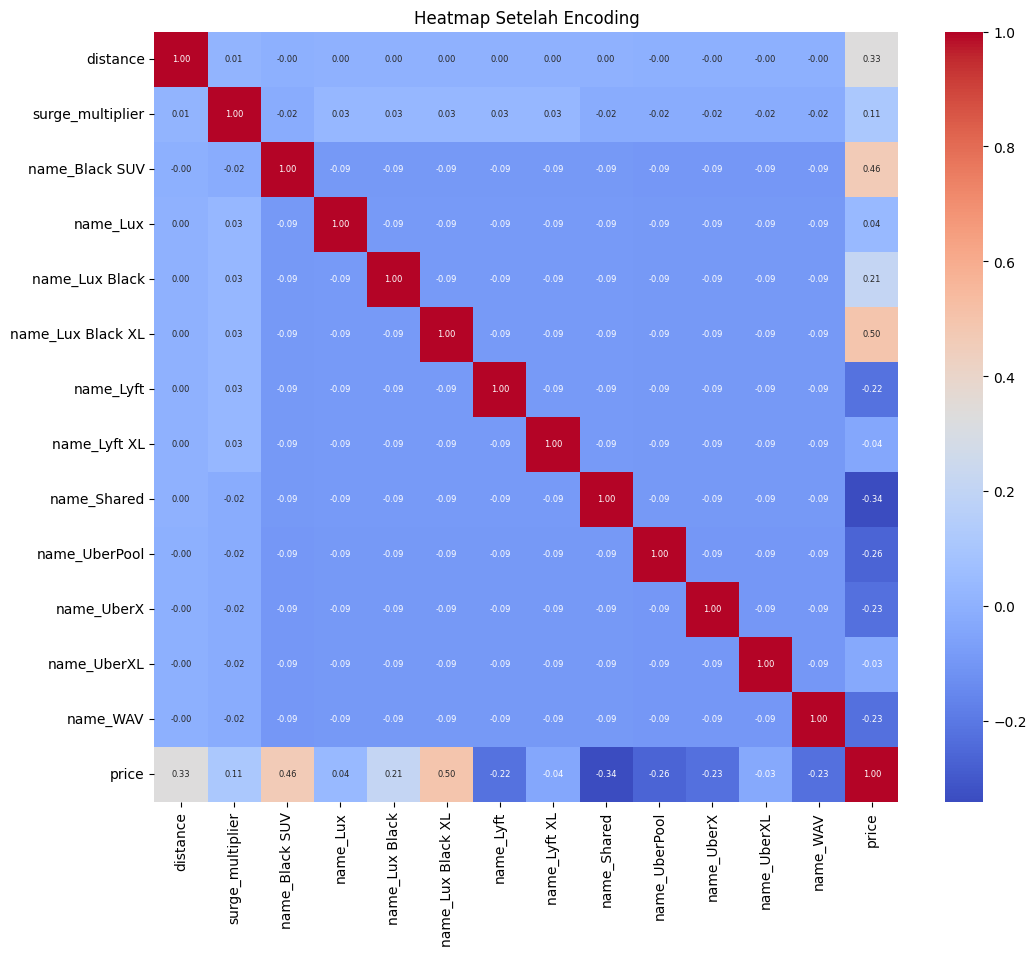

In [107]:
# ==============================
# ANALISIS KORELASI (SETELAH ENCODING)
# ==============================
import seaborn as sns
import matplotlib.pyplot as plt

# Gabungkan fitur (X) dan target (y)
df_corr = X.copy()
df_corr['price'] = y

plt.figure(figsize=(12,10))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 6})
plt.title("Heatmap Setelah Encoding")
plt.show()


In [108]:
# ==============================
# DATA SPLITTING
# ==============================
# Membagi data menjadi training dan testing
from sklearn.model_selection import train_test_split

x_train_70, x_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [109]:
x_train_80, x_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [110]:
x_train_90, x_test_10, y_train_90, y_test_10 = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [111]:
print("70:30", x_train_70.shape, x_test_30.shape)
print("80:20", x_train_80.shape, x_test_20.shape)
print("90:10", x_train_90.shape, x_test_10.shape)

70:30 (446583, 13) (191393, 13)
80:20 (510380, 13) (127596, 13)
90:10 (574178, 13) (63798, 13)


In [112]:
splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

In [113]:
# ==============================
# FUNGSI EVALUASI
# ==============================
# Fungsi untuk menghitung MAE, RMSE, dan R2
def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return mae, rmse, r2

In [114]:
# ==============================
# HYPERPARAMETER TUNING - DECISION TREE
# ==============================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

param_tree = {
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

tree_search = RandomizedSearchCV(
    DecisionTreeRegressor(),
    param_tree,
    n_iter=3,
    cv=2,
    scoring='r2',
    n_jobs=1,
    random_state=42
)

# ===== 70:30 =====
tree_search.fit(x_train_70, y_train_70)
best_tree_70 = tree_search.best_estimator_
y_pred_70 = best_tree_70.predict(x_test_30)

print("Decision Tree (70:30) - TUNED")
print("Best Params:", tree_search.best_params_)
print("MAE :", mean_absolute_error(y_test_30, y_pred_70))
print("RMSE:", np.sqrt(mean_squared_error(y_test_30, y_pred_70)))
print("R2  :", r2_score(y_test_30, y_pred_70))


# ===== 80:20 =====
tree_search.fit(x_train_80, y_train_80)
best_tree_80 = tree_search.best_estimator_
y_pred_80 = best_tree_80.predict(x_test_20)

print("\nDecision Tree (80:20) - TUNED")
print("Best Params:", tree_search.best_params_)
print("MAE :", mean_absolute_error(y_test_20, y_pred_80))
print("RMSE:", np.sqrt(mean_squared_error(y_test_20, y_pred_80)))
print("R2  :", r2_score(y_test_20, y_pred_80))


# ===== 90:10 =====
tree_search.fit(x_train_90, y_train_90)
best_tree_90 = tree_search.best_estimator_
y_pred_90 = best_tree_90.predict(x_test_10)

print("\nDecision Tree (90:10) - TUNED")
print("Best Params:", tree_search.best_params_)
print("MAE :", mean_absolute_error(y_test_10, y_pred_90))
print("RMSE:", np.sqrt(mean_squared_error(y_test_10, y_pred_90)))
print("R2  :", r2_score(y_test_10, y_pred_90))

Decision Tree (70:30) - TUNED
Best Params: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
MAE : 1.844676326868334
RMSE: 2.716169030796333
R2  : 0.9105990329364292

Decision Tree (80:20) - TUNED
Best Params: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
MAE : 1.8421144845689545
RMSE: 2.715400643232198
R2  : 0.91059534400153

Decision Tree (90:10) - TUNED
Best Params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}
MAE : 1.8447318526176362
RMSE: 2.7231893506684526
R2  : 0.909970209469338


In [115]:
# ==============================
# HYPERPARAMETER TUNING - LIGHTGBM
# ==============================
from lightgbm import LGBMRegressor

param_lgbm = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [10, 20],
    "num_leaves": [31, 50]
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(verbose=-1),
    param_lgbm,
    n_iter=3,
    cv=2,
    scoring='r2',
    n_jobs=1,
    random_state=42
)

# ===== 70:30 =====
lgbm_search.fit(x_train_70, y_train_70)
best_lgbm_70 = lgbm_search.best_estimator_
y_pred_70 = best_lgbm_70.predict(x_test_30)

print("LightGBM (70:30) - TUNED")
print("Best Params:", lgbm_search.best_params_)
print("MAE :", mean_absolute_error(y_test_30, y_pred_70))
print("RMSE:", np.sqrt(mean_squared_error(y_test_30, y_pred_70)))
print("R2  :", r2_score(y_test_30, y_pred_70))


# ===== 80:20 =====
lgbm_search.fit(x_train_80, y_train_80)
best_lgbm_80 = lgbm_search.best_estimator_
y_pred_80 = best_lgbm_80.predict(x_test_20)

print("\nLightGBM (80:20) - TUNED")
print("Best Params:", lgbm_search.best_params_)
print("MAE :", mean_absolute_error(y_test_20, y_pred_80))
print("RMSE:", np.sqrt(mean_squared_error(y_test_20, y_pred_80)))
print("R2  :", r2_score(y_test_20, y_pred_80))


# ===== 90:10 =====
lgbm_search.fit(x_train_90, y_train_90)
best_lgbm_90 = lgbm_search.best_estimator_
y_pred_90 = best_lgbm_90.predict(x_test_10)

print("\nLightGBM (90:10) - TUNED")
print("Best Params:", lgbm_search.best_params_)
print("MAE :", mean_absolute_error(y_test_10, y_pred_90))
print("RMSE:", np.sqrt(mean_squared_error(y_test_10, y_pred_90)))
print("R2  :", r2_score(y_test_10, y_pred_90))

LightGBM (70:30) - TUNED
Best Params: {'num_leaves': 50, 'n_estimators': 50, 'max_depth': 20, 'learning_rate': 0.05}
MAE : 1.6340117118296715
RMSE: 2.359349376040346
R2  : 0.932545155793792

LightGBM (80:20) - TUNED
Best Params: {'num_leaves': 50, 'n_estimators': 50, 'max_depth': 20, 'learning_rate': 0.05}
MAE : 1.63292185430614
RMSE: 2.357092021800601
R2  : 0.9326332836377871

LightGBM (90:10) - TUNED
Best Params: {'num_leaves': 50, 'n_estimators': 50, 'max_depth': 20, 'learning_rate': 0.05}
MAE : 1.6312382504090126
RMSE: 2.3603424559743473
R2  : 0.9323635825399262


In [116]:
# ==============================
# HYPERPARAMETER TUNING - LINEAR REGRESSION
# ==============================
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

param_linear = {
    "fit_intercept": [True, False]
}

linear_search = RandomizedSearchCV(
    LinearRegression(),
    param_linear,
    n_iter=2,
    cv=2,
    scoring='r2',
    n_jobs=1
)

# scaler (karena linear butuh scaling)
scaler = StandardScaler()

# ===== 70:30 =====
X_train_70_scaled = scaler.fit_transform(x_train_70)
X_test_30_scaled = scaler.transform(x_test_30)

linear_search.fit(X_train_70_scaled, y_train_70)
best_linear_70 = linear_search.best_estimator_
y_pred_70 = best_linear_70.predict(X_test_30_scaled)

print("Linear Regression (70:30) - TUNED")
print("Best Params:", linear_search.best_params_)
print("MAE :", mean_absolute_error(y_test_30, y_pred_70))
print("RMSE:", np.sqrt(mean_squared_error(y_test_30, y_pred_70)))
print("R2  :", r2_score(y_test_30, y_pred_70))

# ======================
# 80:20
# ======================
X_train_80_scaled = scaler.fit_transform(x_train_80)
X_test_20_scaled = scaler.transform(x_test_20)

linear_search.fit(X_train_80_scaled, y_train_80)

best_linear_80 = linear_search.best_estimator_
y_pred_80 = best_linear_80.predict(X_test_20_scaled)

print("\nLinear Regression (80:20) - TUNED")
print("Best Params:", linear_search.best_params_)
print("MAE :", mean_absolute_error(y_test_20, y_pred_80))
print("RMSE:", np.sqrt(mean_squared_error(y_test_20, y_pred_80)))
print("R2  :", r2_score(y_test_20, y_pred_80))


# ======================
# 90:10
# ======================
X_train_90_scaled = scaler.fit_transform(x_train_90)
X_test_10_scaled = scaler.transform(x_test_10)

linear_search.fit(X_train_90_scaled, y_train_90)

best_linear_90 = linear_search.best_estimator_
y_pred_90 = best_linear_90.predict(X_test_10_scaled)

print("\nLinear Regression (90:10) - TUNED")
print("Best Params:", linear_search.best_params_)
print("MAE :", mean_absolute_error(y_test_10, y_pred_90))
print("RMSE:", np.sqrt(mean_squared_error(y_test_10, y_pred_90)))
print("R2  :", r2_score(y_test_10, y_pred_90))

Linear Regression (70:30) - TUNED
Best Params: {'fit_intercept': True}
MAE : 1.9386040308279406
RMSE: 2.6661926538515233
R2  : 0.9138586477070123

Linear Regression (80:20) - TUNED
Best Params: {'fit_intercept': True}
MAE : 1.936207718183988
RMSE: 2.6633833666857853
R2  : 0.9139878765165748

Linear Regression (90:10) - TUNED
Best Params: {'fit_intercept': True}
MAE : 1.9318668644267571
RMSE: 2.6637552664542605
R2  : 0.9138571567073448
